<a href="https://colab.research.google.com/github/yash-02/Customer-segmentation-Project/blob/main/customer_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
!pip install pandas numpy matplotlib seaborn scikit-learn scipy joblib

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from scipy.stats import ttest_ind, chi2_contingency

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report
)

from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import silhouette_score

sns.set(style="whitegrid")

Upload your dataset from kaggle


In [11]:
import kagglehub
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

Using Colab cache for faster access to the 'telco-customer-churn' dataset.


In [12]:
path

'/kaggle/input/telco-customer-churn'

In [13]:
import os

file_list = os.listdir(path)
print(f"Files in the directory {path}: {file_list}")

csv_file_name = None
for f in file_list:
    if f.endswith('.csv'):
        csv_file_name = f
        break

if csv_file_name:
    full_csv_path = os.path.join(path, csv_file_name)
    df = pd.read_csv(full_csv_path)
    print("DataFrame loaded successfully.")
    print(df.head())
else:
    print("No CSV file found in the downloaded directory.")

Files in the directory /kaggle/input/telco-customer-churn: ['WA_Fn-UseC_-Telco-Customer-Churn.csv']
DataFrame loaded successfully.
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4       

understand size, column types, missing values, and the target column.

In [14]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [15]:
target_col = "Churn"
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nData types:\n", df.dtypes)

Shape: (7043, 21)

Columns:
 ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
 customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [16]:
print("\nMissing values:\n", df.isnull().sum().sort_values(ascending=False).head(20))
print("\nDuplicate rows:", df.duplicated().sum())


Missing values:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
dtype: int64

Duplicate rows: 0


In [17]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [18]:
df[target_col]

,Churn
0,No
1,No
2,Yes
3,No
4,Yes
...,...
7038,No
7039,No
7040,No
7041,Yes


# Clean the target column
ML models need the churn target in 0/1 format.




In [19]:
if df[target_col].dtype == "object":
    df[target_col] = df[target_col].astype(str).str.strip().str.lower().map({
        "yes": 1, "no": 0,
        "true": 1, "false": 0,
        "1": 1, "0": 0
    })

df[target_col] = df[target_col].astype(int)
print(df[target_col].value_counts())
print("Churn rate:", df[target_col].mean())

Churn
0    5174
1    1869
Name: count, dtype: int64
Churn rate: 0.2653698707936959


##Convert numeric-looking text columns

Why: Real datasets often store numbers as text, which breaks analysis.

below code is acting like an automated cleaner for your dataset. It hunts for columns that are disguised as text but are actually meant to be numbers, and fixes them so your data analysis tools can actually use them.

Here is a breakdown of exactly how this works, step by step.

The Real-World Analogy
Imagine you have a spreadsheet column for "Monthly Bill." Most entries say 50.00 or 75.50, but a few entries have typos, like a stray space (50.00) or a note ("Free trial"). Because of those few weird entries, Python throws its hands up and labels the entire column as text.

If you try to calculate the average "Monthly Bill," Python will crash because it doesn't know how to do math on text. This code automatically finds those disguised columns, forces the valid numbers into a math-friendly format, and turns the weird text (like "Free trial") into blanks

In [20]:
for col in df.columns:
    if df[col].dtype == "object" and col != target_col:
        converted = pd.to_numeric(df[col], errors="coerce")
        if converted.notna().sum() > 0:
            if converted.notna().sum() / len(df) > 0.7:
                df[col] = converted

df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


7) Descriptive analysis

Why: This tells us the average, spread, and distribution of the data.

In [21]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


For numeric columns:

In [22]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.00,0.000,0.0000,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.000,55.0000,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.350,89.8500,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.45,1397.475,3794.7375,8684.80
Churn,7043.0,0.265370,0.441561,0.00,0.00,0.000,1.0000,1.00


For categorical columns:

In [23]:
cat_cols = df.select_dtypes(include="object").columns.tolist()
for col in cat_cols[:10]:
    print("\nColumn:", col)
    print(df[col].value_counts(dropna=False).head(10))


Column: customerID
customerID
3186-AJIEK    1
7590-VHVEG    1
5575-GNVDE    1
8775-CEBBJ    1
2823-LKABH    1
7398-LXGYX    1
1035-IPQPU    1
7203-OYKCT    1
1699-HPSBG    1
9837-FWLCH    1
Name: count, dtype: int64

Column: gender
gender
Male      3555
Female    3488
Name: count, dtype: int64

Column: Partner
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Column: Dependents
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

Column: PhoneService
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

Column: MultipleLines
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

Column: InternetService
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

Column: OnlineSecurity
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

Column: OnlineBackup
OnlineBackup
No            

8) Visualize the target distribution

Why: We must see whether churn is imbalanced.

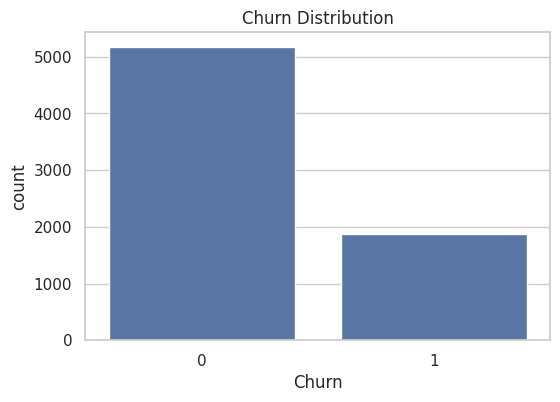

In [24]:
plt.figure(figsize=(6,4))
sns.countplot(x=target_col, data=df)
plt.title("Churn Distribution")
plt.show()

9) Numeric distributions

Why: This helps us understand skewness, spread, and outliers.

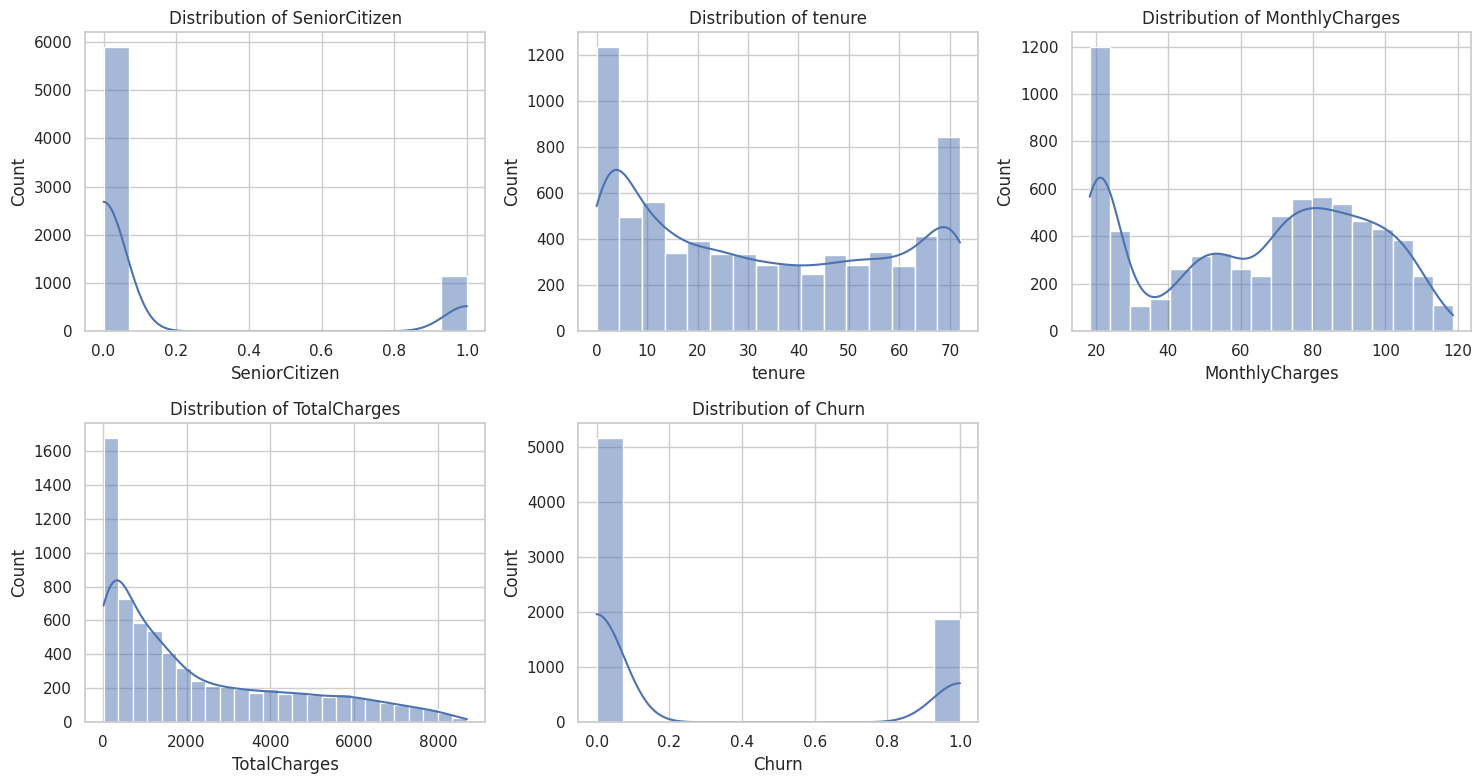

In [25]:
n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

pd.crosstab(): This function is used to compute a frequency table of two or more factors.
df['SeniorCitizen']: This is the first variable used for grouping, indicating whether a customer is a senior citizen.
df['Churn']: This is the second variable, representing whether a customer churned.
normalize='index': This argument normalizes the values across each row (index)

In [26]:
pd.crosstab(
    df['SeniorCitizen'],
    df['Churn'],
    normalize='index'
)

Churn,0,1
SeniorCitizen,,
0,0.763938,0.236062
1,0.583187,0.416813


in analysis

When we ask:

"Do senior citizens churn more?"

we mean:

"Are senior citizens more likely to leave the company than non-senior citizens?"

For example:

SeniorCitizen	Churn Rate

Interpretation:

Non-Senior Customers:
24% leave

Senior Customers:
42% leave

This would tell us:

Senior citizens are much more likely to churn.

and the business may create special retention programs for them.

10) Boxplots by churn

Why: We want to see whether churned and non-churned customers differ.

<Axes: xlabel='Churn', ylabel='tenure'>

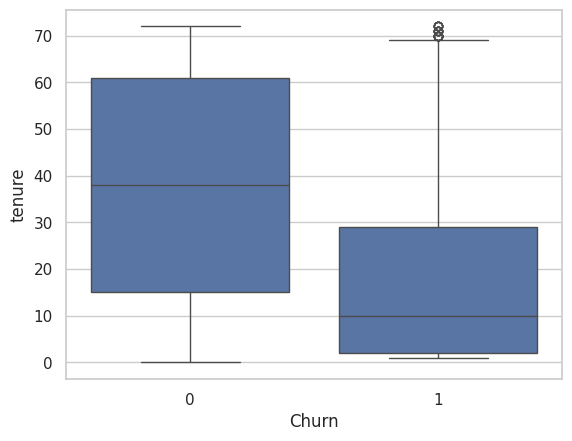

In [27]:
sns.boxplot(
    x='Churn',
    y='tenure',
    data=df
)

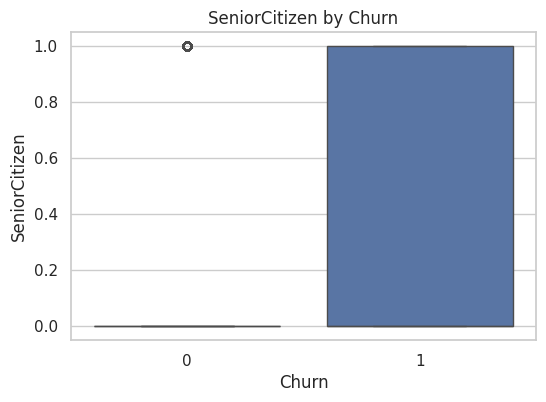

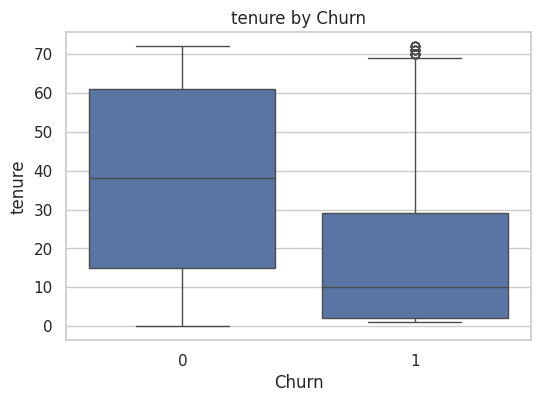

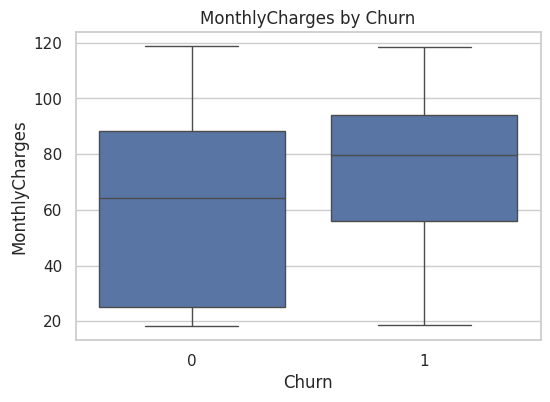

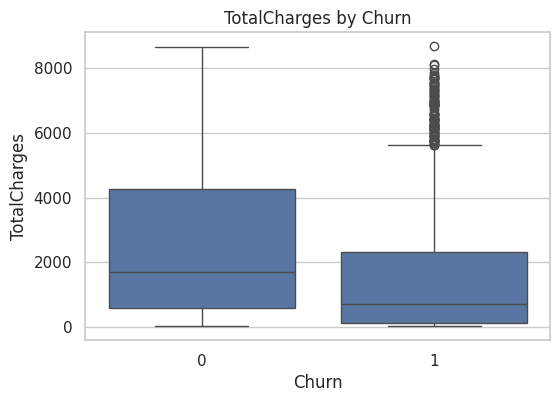

In [28]:
for col in num_cols[:6]:
    if col != target_col:
        plt.figure(figsize=(6,4))
        sns.boxplot(x=target_col, y=col, data=df)
        plt.title(f"{col} by Churn")
        plt.show()

11) Categorical features vs churn

Why: This shows whether specific categories are linked to churn.

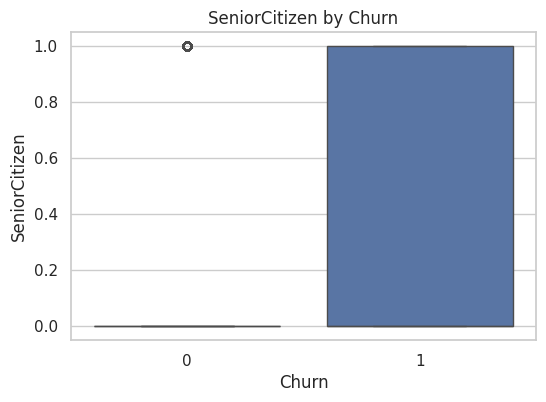

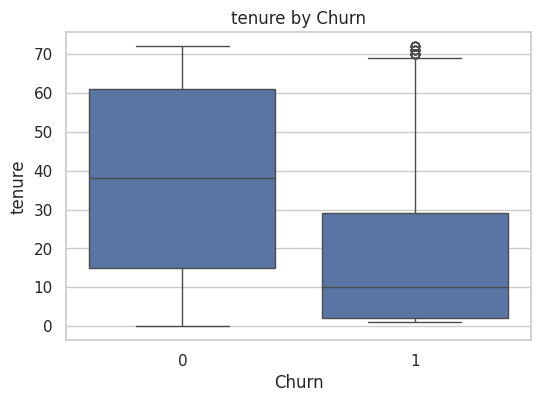

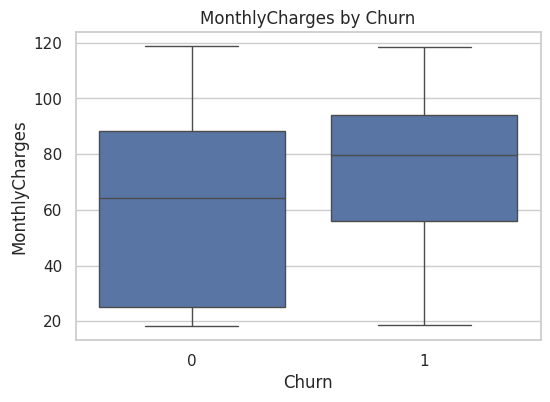

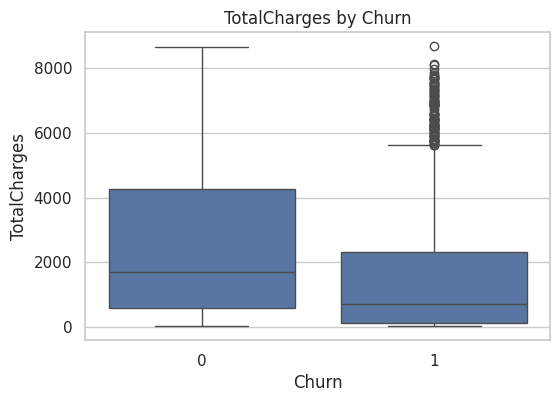

In [29]:
for col in num_cols[:6]:
    if col != target_col:
        plt.figure(figsize=(6,4))
        sns.boxplot(x=target_col, y=col, data=df)
        plt.title(f"{col} by Churn")
        plt.show()

12) Correlation heatmap

Why: This helps us detect strong numeric relationships.

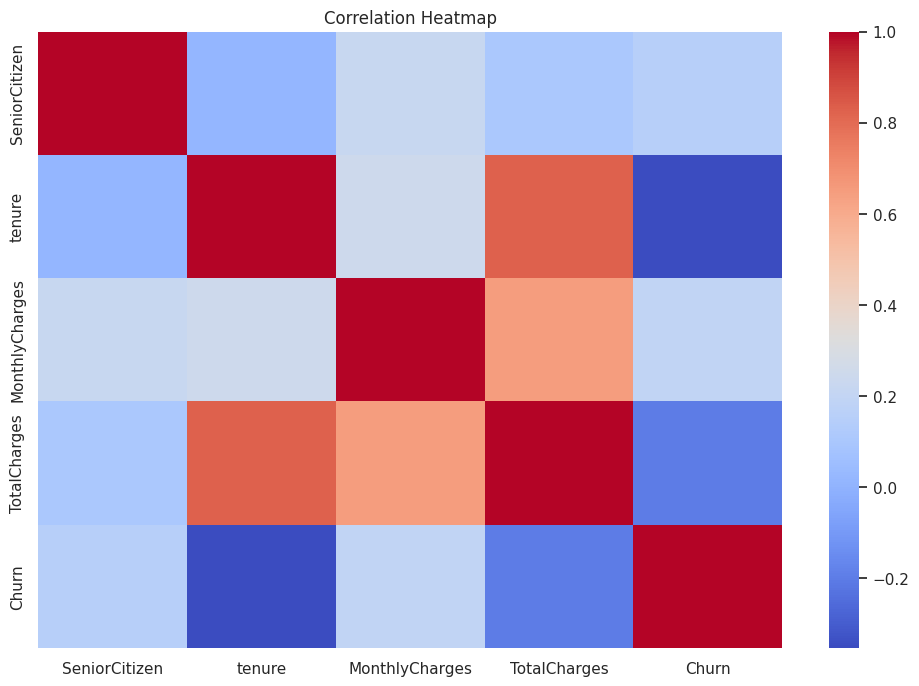

In [30]:
plt.figure(figsize=(12,8))
sns.heatmap(df[num_cols].corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


13) Hypothesis testing

Why: This gives statistical evidence, not just visual guesses.

13A) t-test for numeric columns

Question: Is the mean different between churned and non-churned customers?

In [31]:
t_test_results = []

for col in num_cols:
    if col != target_col:
        g0 = df[df[target_col] == 0][col].dropna()
        g1 = df[df[target_col] == 1][col].dropna()
        if len(g0) > 1 and len(g1) > 1:
            stat, p = ttest_ind(g0, g1, equal_var=False)
            t_test_results.append([col, stat, p])

t_test_df = pd.DataFrame(t_test_results, columns=["feature", "t_stat", "p_value"])
t_test_df = t_test_df.sort_values("p_value")
t_test_df.head(10)

,feature,t_stat,p_value
1,tenure,34.823819,1.195495e-232
3,TotalCharges,18.800768,1.152494e-75
2,MonthlyCharges,-18.407527,8.592449e-73
0,SeniorCitizen,-11.343877,3.587587e-29


The Rule: A p-value < 0.05 is the standard scientific threshold to declare a result "statistically significant." * All your results here have extremely tiny p-values (the e-232 means the decimal point is moved 232 places to the left). This means these features are definitely related to whether a customer churns.

t-stat (T-statistic): This indicates the direction and strength of the difference.

A positive number means the average for "stayed" customers is higher.

A negative number means the average for "stayed" customers is lower.

What the Results Tell Us
Based on this table, you have found strong evidence that these four features are powerful predictors of customer churn:

Tenure: Highly significant. There is a very strong relationship between how long a customer stays and whether they churn.

TotalCharges & MonthlyCharges: Both are highly significant, confirming that cost is a major factor in customer decisions.

SeniorCitizen: Also significant, suggesting that age group plays a measurable role in whether someone stays or leaves.

In [32]:
print("Features with p < 0.05 are statistically significant.")
print(t_test_df[t_test_df["p_value"] < 0.05].head(10))

Features with p < 0.05 are statistically significant.
          feature     t_stat        p_value
1          tenure  34.823819  1.195495e-232
3    TotalCharges  18.800768   1.152494e-75
2  MonthlyCharges -18.407527   8.592449e-73
0   SeniorCitizen -11.343877   3.587587e-29


13B) Chi-square test for categorical columns

Question: Is the category associated with churn?

In [33]:
chi_results = []

for col in cat_cols:
    if col != target_col:
        table = pd.crosstab(df[col].fillna("Missing"), df[target_col])
        if table.shape[0] > 1 and table.shape[1] == 2:
            stat, p, dof, expected = chi2_contingency(table)
            chi_results.append([col, stat, p])

chi_df = pd.DataFrame(chi_results, columns=["feature", "chi2_stat", "p_value"]).sort_values("p_value")
chi_df.head(10)

,feature,chi2_stat,p_value
13,Contract,1184.596572,5.863038e-258
7,OnlineSecurity,849.998968,2.661150e-185
10,TechSupport,828.197068,1.443084e-180
6,InternetService,732.309590,9.571788e-160
15,PaymentMethod,648.142327,3.682355e-140
8,OnlineBackup,601.812790,2.079759e-131
9,DeviceProtection,558.419369,5.505219e-122
12,StreamingMovies,375.661479,2.667757e-82
11,StreamingTV,374.203943,5.528994e-82
14,PaperlessBilling,258.277649,4.073355e-58


14) Define feature columns

Why: We separate input features from target.

In [34]:
id_cols = []   # add IDs here if you have them, like ["customerID"]

X = df.drop(columns=[target_col] + id_cols, errors="ignore")
y = df[target_col]

num_features = X.select_dtypes(include=np.number).columns.tolist()
cat_features = X.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric:", num_features)
print("Categorical:", cat_features)

Numeric: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


15) Preprocessing pipeline

Why: We need missing-value handling, scaling, and one-hot encoding.

In [35]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, num_features),
    ("cat", categorical_pipeline, cat_features)
])

16) Train-test split

Why: We must evaluate on unseen data.

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

17) Train churn models

Why: Start with a simple baseline, then try a stronger model.

Logistic Regression

In [37]:
log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=3000, class_weight="balanced"))
])

log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)
log_proba = log_model.predict_proba(X_test)[:, 1]

Random Forest

In [38]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced_subsample",
        min_samples_leaf=2
    ))
])

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

18) Evaluate models

Why: Accuracy alone is not enough. We need recall, precision, F1, ROC-AUC, and PR-AUC.

In [39]:
def evaluate_model(y_true, pred, proba, name):
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_true, pred))
    print("Precision:", precision_score(y_true, pred))
    print("Recall:", recall_score(y_true, pred))
    print("F1:", f1_score(y_true, pred))
    print("ROC-AUC:", roc_auc_score(y_true, proba))
    print("PR-AUC:", average_precision_score(y_true, proba))
    print("\nClassification Report:\n", classification_report(y_true, pred))

evaluate_model(y_test, log_pred, log_proba, "Logistic Regression")
evaluate_model(y_test, rf_pred, rf_proba, "Random Forest")


Logistic Regression
Accuracy: 0.7530163236337828
Precision: 0.5241635687732342
Recall: 0.7540106951871658
F1: 0.618421052631579
ROC-AUC: 0.8408897155700223
PR-AUC: 0.6321331007099908

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.75      0.82      1035
           1       0.52      0.75      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.75      0.76      1409


Random Forest
Accuracy: 0.7019162526614621
Precision: 0.4649390243902439
Recall: 0.8155080213903744
F1: 0.5922330097087378
ROC-AUC: 0.8094809992508202
PR-AUC: 0.5933278324790957

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.66      0.77      1035
           1       0.46      0.82      0.59       374

    accuracy                           0.70      1409
   macro avg       0.69      0.74      0.6

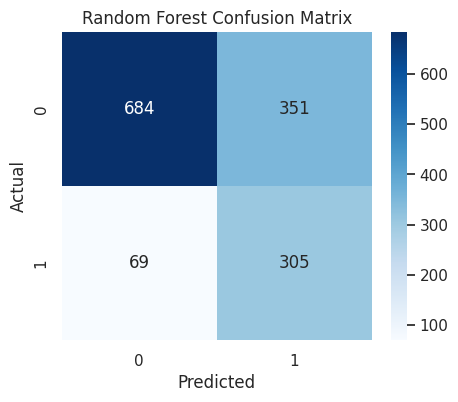

In [40]:
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

20) Save the best churn model

Why: So we can use it later without retraining.

In [41]:
joblib.dump(rf_model, "churn_model.joblib")

['churn_model.joblib']

21) Make churn predictions for all customers

Why: This creates business-ready output.

In [43]:
df["churn_probability"] = rf_model.predict_proba(X)[:, 1]
df["predicted_churn"] = (df["churn_probability"] >= 0.5).astype(int)

df[["churn_probability", "predicted_churn"]]

,churn_probability,predicted_churn
0,0.522677,1
1,0.473458,0
2,0.506185,1
3,0.465171,0
4,0.545461,1
...,...,...
7038,0.461238,0
7039,0.491810,0
7040,0.499100,0
7041,0.537149,1


Top risky customers:

In [44]:
df.sort_values("churn_probability", ascending=False).head(20)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,churn_probability,predicted_churn
2589,7576-OYWBN,Male,1,No,No,3,Yes,Yes,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,76.05,231.80,1,0.551031,1
5481,8473-VUVJN,Male,1,No,No,1,Yes,Yes,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,73.65,73.65,1,0.551031,1
1505,5240-IJOQT,Male,1,No,No,1,Yes,Yes,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,74.70,74.70,1,0.551031,1
3495,4988-IQIGL,Male,1,No,No,1,Yes,Yes,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,75.35,75.35,1,0.551031,1
7032,6894-LFHLY,Male,1,No,No,1,Yes,Yes,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,75.75,75.75,1,0.551031,1
6438,3551-HUAZH,Male,1,No,No,1,Yes,Yes,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,74.40,74.40,1,0.551031,1
6623,9248-OJYKK,Male,1,No,No,1,Yes,Yes,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,76.45,76.45,1,0.551031,1
5098,8258-GSTJK,Male,1,No,No,3,Yes,Yes,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,77.00,237.75,1,0.551031,1
3078,5277-ZLOOR,Female,1,No,No,2,Yes,Yes,Fiber optic,No,...,Yes,No,Month-to-month,Yes,Electronic check,85.55,187.45,1,0.549988,1
585,5192-EBGOV,Female,1,No,No,1,Yes,Yes,Fiber optic,No,...,Yes,No,Month-to-month,Yes,Electronic check,85.70,85.70,1,0.549988,1


22) Customer segmentation

Why: Churn tells us who may leave. Segmentation tells us which customer groups exist.

We will cluster customers using the same feature set.

In [45]:
seg_X = df.drop(columns=[target_col, "churn_probability", "predicted_churn"] + id_cols, errors="ignore")
seg_num = seg_X.select_dtypes(include=np.number).columns.tolist()
seg_cat = seg_X.select_dtypes(exclude=np.number).columns.tolist()

Preprocess for clustering:

In [46]:
seg_preprocessor = ColumnTransformer(transformers=[
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), seg_num),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), seg_cat)
])

seg_transformed = seg_preprocessor.fit_transform(seg_X)

23) Find the best number of clusters

Why: We need a reasonable number of customer groups.

In [47]:
scores = []

for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(seg_transformed)
    score = silhouette_score(seg_transformed, labels)
    scores.append((k, score))

score_df = pd.DataFrame(scores, columns=["k", "silhouette_score"])
score_df

,k,silhouette_score
0,2,0.217792
1,3,0.217579
2,4,0.211127
3,5,0.176216
4,6,0.162877
5,7,0.166913
6,8,0.131818


Plot:

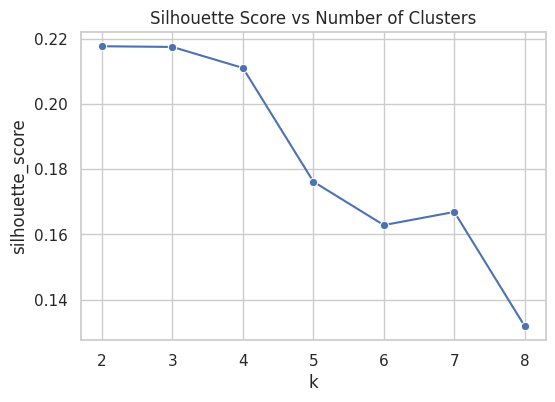

In [48]:
plt.figure(figsize=(6,4))
sns.lineplot(data=score_df, x="k", y="silhouette_score", marker="o")
plt.title("Silhouette Score vs Number of Clusters")
plt.show()

Choose best k:

In [49]:
best_k = score_df.sort_values("silhouette_score", ascending=False).iloc[0]["k"]
best_k = int(best_k)
print("Best k:", best_k)

Best k: 2


24) Fit KMeans

Why: This assigns each customer to a segment.

In [51]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(seg_transformed)

df["cluster"].value_counts().sort_index()

,count
cluster,
0,1526
1,5517


In [52]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(seg_transformed)

df["cluster"].value_counts().sort_index()

,count
cluster,
0,1526
1,5517


25) Visualize clusters in 2D

Why: This gives a simple picture of the segments.

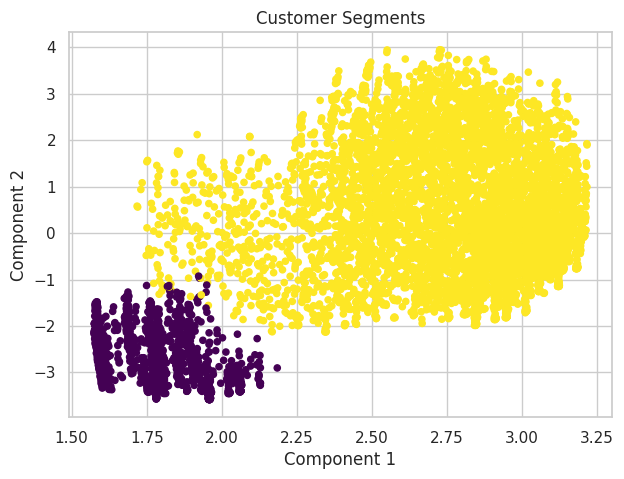

In [53]:
svd = TruncatedSVD(n_components=2, random_state=42)
coords = svd.fit_transform(seg_transformed)

plt.figure(figsize=(7,5))
plt.scatter(coords[:, 0], coords[:, 1], c=df["cluster"], cmap="viridis", s=20)
plt.title("Customer Segments")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

26) Profile each segment

Why: We need to understand what each cluster means.

In [54]:
cluster_profile = df.groupby("cluster")[num_features].mean(numeric_only=True)
cluster_profile

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
cluster,,,,
0,0.034076,30.547182,21.079194,665.220329
1,0.197571,32.875657,76.844254,2729.505406


In [56]:
df["cluster"].value_counts().sort_index()

,count
cluster,
0,1526
1,5517


In [57]:
df["cluster"].value_counts().sort_index()

,count
cluster,
0,1526
1,5517


In [58]:
df.groupby("cluster")[target_col].mean().sort_values(ascending=False)

,Churn
cluster,
1,0.318289
0,0.074050


In [59]:
df.to_csv("final_churn_segmentation_output.csv", index=False)
joblib.dump(kmeans, "customer_segmentation_kmeans.joblib")
joblib.dump(seg_preprocessor, "segmentation_preprocessor.joblib")

['segmentation_preprocessor.joblib']